# Function 3

<b> Description of the Sample Application:</b> You’re working on a drug discovery project, testing combinations of three compounds to create a new medicine.
Each experiment is stored in initial_inputs.npy as a 3D array, where each row lists the amounts of the three compounds used. After each experiment, you record the number of adverse reactions, stored in initial_outputs.npy as a 1D array.
Your goal is to minimise side effects; in this competition, it is framed as maximisation by optimising a transformed output (e.g. the negative of side effects). 



## Change Log

| Date | Week | Changes Made |
|---|---|---|
| 22/07/2026 | Week 1 | 1. Initial Version with 10 Data Point |
| 22/07/2026 | Week 2 | 1. Added Change Log and Progress Log.<br>2. Added new data point. |


## Progress Log

| Round | # Data Points | Method / Acquisition | beta (kappa) | Best x (compound_1, compound_2, compound_3) | Best y | Notes |
|---|---|---|---|---|---|---|
|  |  |  |  |  |  |  |
| Week 1 | 15  | GP-UCB | 2.5 (exploration-heavy) | [0.4926, 0.6116, 0.3402] (unchanged - query point was new) | -0.0348 | Queried [0.989736, 0.937592, 0.849609] -> y = -0.0498. Uncertainty-driven pick near domain edge |
| Week 2  | 16 | GP-UCB, kernel re-selected via LOO CV | 1.0 (exploitation-leaning) | [0.4926, 0.6116, 0.3402] (still current best) | -0.0348 | Appended Week 1 feedback, cross-validated kernel choice (Matern selected), lowered beta, checked for a second optimum |


In [132]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel, Matern
from sklearn.model_selection import LeaveOneOut

from plotting_utils import plot_convergence, plot_parallel_coordinates

# Load and Analyse the Data

In [19]:
# File Names
input_file  = "initial_inputs.npy"
output_file = "initial_outputs.npy"

# Load the Files
X0      = np.load(input_file)
Y0      = np.load(output_file)


# New data from the first submission (example inputs and outputs)
X_w1_new_point = np.array([0.989736, 0.937592, 0.849609]   , dtype=np.float64)    # from input.txt
Y_w1_new_point = np.array([-0.04976805147714386]          , dtype=np.float64)    # from output.txt

# Append the new data points
X_updated      = np.vstack((X0, X_w1_new_point))
Y_updated      = np.append(Y0, Y_w1_new_point)

print(X_updated)
print(Y_updated)

# Save the updated arrays
#np.save(r"initial_inputs.npy", X_updated)
#np.save(r"initial_outputs.npy", Y_updated)

[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.989736   0.937592   0.849609  ]]
[-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.04976805]


In [23]:
# Assign X = X_updated and Y = Y_updated
X          = X_updated
Y          = Y_updated

# Analyse the Input Data
print("Input  Shape:", X.shape)
print("Inputs:\n", X)
print()

# Analyse the Output Data
print("Output Shape:", Y.shape)
print("Outputs:\n", Y)
print()

print(f"Y Range: [: {Y.min()}, {Y.max()}]")
best_idx   = np.argmax(Y)
print(f"Best point: x = {X[best_idx]}, Y = {Y[best_idx]}")
print()

# Converting the Input and Output into a DataFram
df         = pd.DataFrame(X, columns = [f'X_{i+1}' for i in range(X.shape[1])])
df['Y']    = Y
print("Data Frame:\n", df)

Input  Shape: (16, 3)
Inputs:
 [[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.21991724 0.45820622]
 [0.34552327 0.94135983 0.26936348]
 [0.15183663 0.43999062 0.99088187]
 [0.64550284 0.39714294 0.91977134]
 [0.74691195 0.28419631 0.22629985]
 [0.17047699 0.6970324  0.14916943]
 [0.22054934 0.29782524 0.34355534]
 [0.66601366 0.67198515 0.2462953 ]
 [0.04680895 0.23136024 0.77061759]
 [0.60009728 0.72513573 0.06608864]
 [0.96599485 0.86111969 0.56682913]
 [0.989736   0.937592   0.849609  ]]

Output Shape: (16,)
Outputs:
 [-0.1121222  -0.08796286 -0.11141465 -0.03483531 -0.04800758 -0.11062091
 -0.39892551 -0.11386851 -0.13146061 -0.09418956 -0.04694741 -0.10596504
 -0.11804826 -0.03637783 -0.05675837 -0.04976805]

Y Range: [: -0.3989255131463011, -0.034835313350078584]
Best point: x = [0.49258141 0.61159319 0.34017639], Y = -0.034835313350078584

Data Frame:
          X_1    

# Data Exploration

In [26]:
# Basic Staistics
print("Display Basic Statistics for the Dataset\n",df.describe())

Display Basic Statistics for the Dataset
              X_1        X_2        X_3          Y
count  16.000000  16.000000  16.000000  16.000000
mean    0.445325   0.543921   0.430714  -0.103580
std     0.302787   0.248332   0.296365   0.085428
min     0.046809   0.219917   0.066089  -0.398926
25%     0.171263   0.332394   0.241296  -0.112559
50%     0.419052   0.525792   0.306305  -0.100077
75%     0.650631   0.704058   0.617776  -0.049328
max     0.989736   0.941360   0.990882  -0.034835


In [28]:
# Check for Missing Values in the Data Set
print("Missing Values in the Dataset\n",df.isnull().sum())

Missing Values in the Dataset
 X_1    0
X_2    0
X_3    0
Y      0
dtype: int64


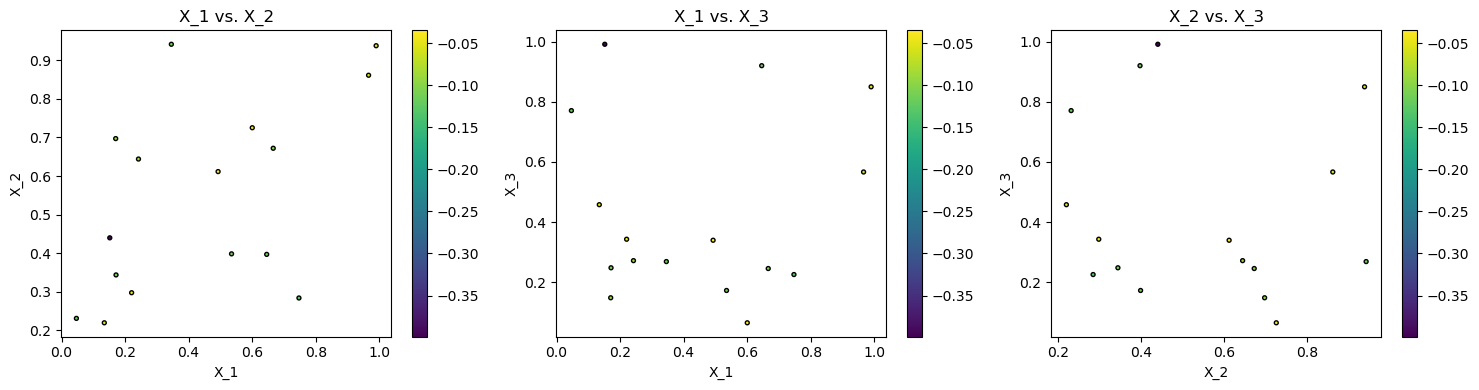

In [30]:
# Pairwise Scatter Plot
labels      = ["X_1", "X_2", "X_3"]
fig, axes   = plt.subplots(1, 3, figsize = (15, 4))
pairs       = [(0, 1), (0, 2), (1, 2)]
for ax, (i, j) in zip(axes, pairs):
    sc      = ax.scatter(X[:, i], X[:, j], c = Y, cmap = "viridis", s = 8, edgecolor = "k")
    ax.set_xlabel(labels[i])
    ax.set_ylabel(labels[j])
    ax.set_title(f"{labels[i]} vs. {labels[j]}")
    plt.colorbar(sc, ax = ax)
plt.tight_layout()

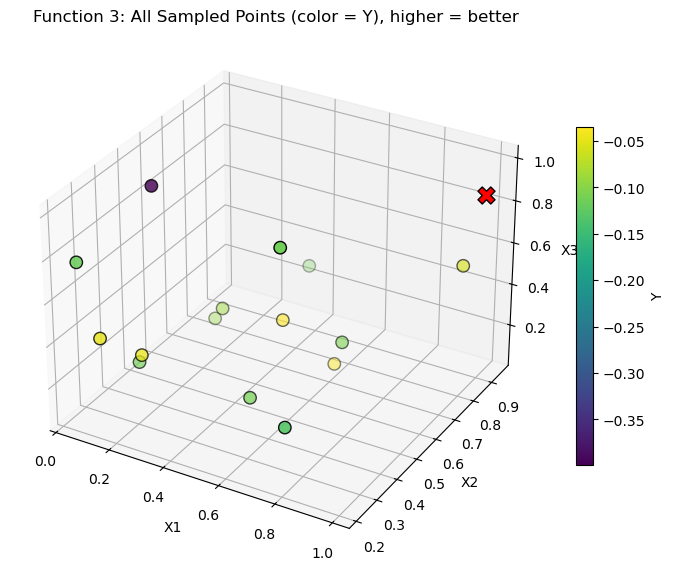

In [42]:
# 3D Scatter Plot
fig       = plt.figure(figsize = (7,6))
ax        = fig.add_subplot(111, projection = "3d")
sc        = ax.scatter(X[:-1,0], X[:-1,1], X[:-1, 2], c = Y[:-1], cmap = "viridis", s = 80, edgecolor = "k", label="Initial + prior queries")

ax.scatter(X[-1, 0], X[-1, 1], X[-1, 2], c = "red", marker = "X", s = 150, edgecolor = "black", label = "Week 1 new point")
    
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("X3")
ax.set_title('Function 3: All Sampled Points (color = Y), higher = better')
fig.colorbar(sc, shrink = 0.6, label = "Y")
plt.tight_layout()
plt.show()

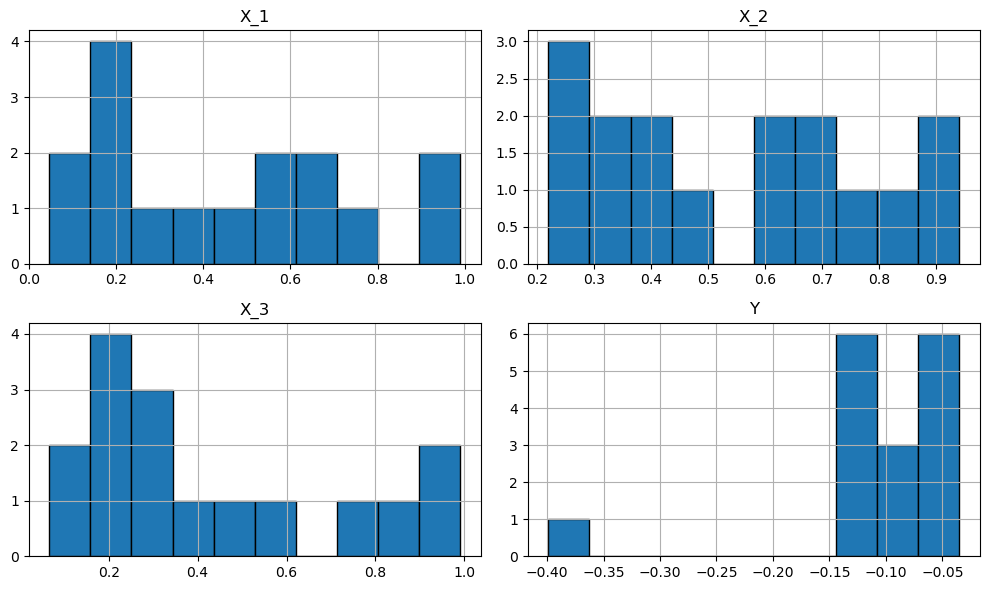

In [34]:
# Plot Histogram Visualisation for the columns of the DataFrame
df.hist(figsize = (10, 6), bins = 10, edgecolor = 'k' )
plt.tight_layout()
plt.show()

In [36]:
# Understanding Correlation between each drug 
print("Correlation of each drug with Y:\n")

for i, lab in enumerate(labels):
    corr = np.corrcoef(X[:, i],Y)[0, 1]
    print(f" corr({lab}, Y) = {corr}")

Correlation of each drug with Y:

 corr(X_1, Y) = 0.29733588147772727
 corr(X_2, Y) = 0.21255436967422328
 corr(X_3, Y) = -0.4605026532074378


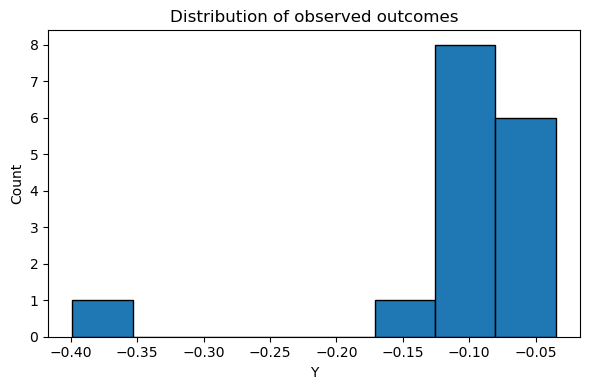

In [38]:
# Plot the Histogram for Y to check for Outliers
plt.figure(figsize = (6,4))
plt.hist(Y, bins = 8, edgecolor = "k")
plt.xlabel("Y")
plt.ylabel("Count")
plt.title("Distribution of observed outcomes")
plt.tight_layout()

# Initialize Gaussian Process

In [29]:
#Define the kernel and initialise the GP model

kernel_rbf = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10)) \
                + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-2, 1e-1))
gpr   = GaussianProcessRegressor(kernel = kernel_rbf, normalize_y = True, n_restarts_optimizer = 10, random_state = 0 )

# Fit the Gaussian Processes to existing data

In [32]:
# Train the model

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  1.5**2 * RBF(length_scale=[10, 10, 0.0806]) + WhiteKernel(noise_level=0.014)


C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\mitra\anaconda3\Lib\site-packages\sklearn\gaussian_process\kernels.py:455: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


# Compute the UCB acquisition function

- UCB(x)=μ(x)+β⋅σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- Week 1 uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.

In [36]:
n_candidates = 50000
candidates   = np.random.uniform(0, 1, size = (n_candidates, 3))

mu, std      = gpr.predict(candidates, return_std = True)

# Setting a higher beta(= 2.5) for Week -1
beta         = 2.5
ucb          = mu + beta * std

best_ucb_idx   = np.argmax(ucb)
next_point     = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [0.98973577 0.93759164 0.84960875]
Predicted Mean(μ): -1.284797e-02
Predicted Std (σ): 5.959945e-02
UCB Score: 1.361507e-01


# Perform Visualisation

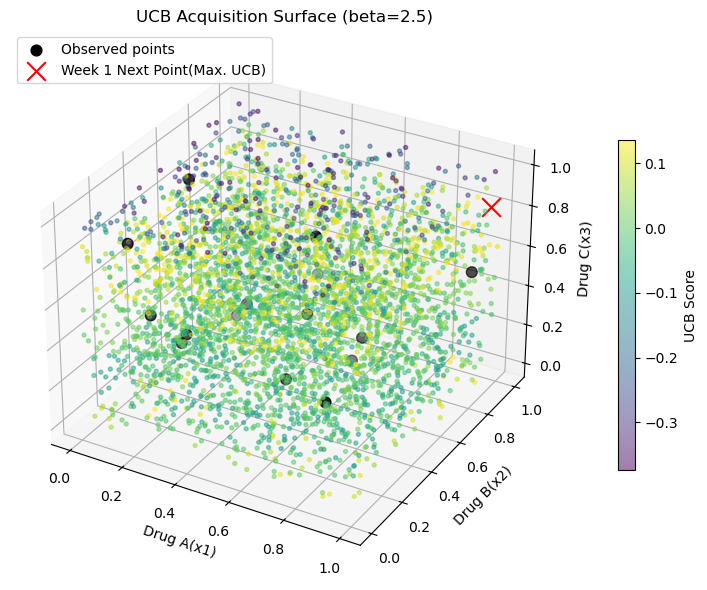

In [39]:
plot_n     = 4000
idx_sample = np.random.choice(n_candidates, size = plot_n, replace = False)
fig        = plt.figure(figsize = (12, 6))
ax         = fig.add_subplot(111, projection = "3d")
sc         = ax.scatter(candidates[idx_sample, 0],
                        candidates[idx_sample, 1],
                        candidates[idx_sample, 2],
                        c = ucb[idx_sample], cmap = "viridis", s = 8, alpha = 0.5
                       )


ax.scatter(X[:, 0], X[:, 1], X[:, 2], c = "black", s = 60, marker = "o", label="Observed points")
ax.scatter(*next_point, c = "red", s = 180, marker = "x", label="Week 1 Next Point(Max. UCB)")
ax.set_xlabel("Drug A(x1)")
ax.set_ylabel("Drug B(x2)")
ax.set_zlabel("Drug C(x3)")
ax.set_title("UCB Acquisition Surface (beta=2.5)")
fig.colorbar(sc, shrink = 0.6, label = "UCB Score")
ax.legend(loc = "upper left")
plt.tight_layout()
plt.show()

# Week 2 Improvements: Kernel Selection via Leave-One-Out Cross-Validation
Following up from the reflection at the end of Week 1, cross-validating if RBF kernel was the right choice. Here RBF is compared against a Matern(nu = 1.5) kernel using leave-one-out RMSE, and use whichever fits the data better.

In [134]:
def loo_rmse(kernel, X, Y):
    """Leave-one-out RMSE for a given GP kernel."""
    loo     = LeaveOneOut()
    preds   = np.zeros_like(Y)
    for train_idx, test_idx in loo.split(X):
        gp              = GaussianProcessRegressor(kernel = kernel, normalize_y = True, n_restarts_optimizer = 5, random_state = 0)
        gp.fit(X[train_idx], Y[train_idx])
        preds[test_idx] = gp.predict(X[test_idx])
    return np.sqrt(mean_squared_error(Y, preds))

rbf_kernel  = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10)) \
                  + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

matern_kernel = ConstantKernel(1.0, (1e-2, 1e2)) * Matern(length_scale = [0.3, 0.3, 0.3], length_scale_bounds = (1e-2, 10), nu = 1.5) \
                  + WhiteKernel(noise_level = 1e-3, noise_level_bounds = (1e-6, 1e-1))

rmse_rbf    = loo_rmse(rbf_kernel, X, Y)

rmse_matern = loo_rmse(matern_kernel, X, Y)

print(f"RBF    LOO RMSE = {rmse_rbf:.4f}")
print(f"Matern LOO RMSE = {rmse_matern:.4f}")

if rmse_rbf <= rmse_matern:
    chosen_kernel, chosen_name = rbf_kernel, "RBF"
else:
    chosen_kernel, chosen_name = matern_kernel, "Matern"

print(f"\nSelected kernel for Week 2: {chosen_name}")


RBF    LOO RMSE = 0.0993
Matern LOO RMSE = 0.0903

Selected kernel for Week 2: Matern


# Week 2: Fit the Gaussian Process Surrogate Model

In [63]:
# Train the model

gpr  = GaussianProcessRegressor(kernel = chosen_kernel, normalize_y = True, n_restarts_optimizer = 10, random_state = 0)

gpr.fit(X, Y)
print("Learned kernel: ", gpr.kernel_)

Learned kernel:  1.36**2 * Matern(length_scale=[10, 10, 0.1], nu=1.5) + WhiteKernel(noise_level=0.0144)


# Week 2: Compute the UCB acquisition function ( Lower β )
- UCB(x) = μ(x) + β * σ(x)
- A high beta favors exploration (uncertainty) over exploitation (predicted mean).
- **Week 1:** uses beta = 2.5, reflecting the 90:10 exploration-heavy strategy.
- **Week 2:** uses beta = 1.0, β is lowered this week to shift the explore-exploit balance toward exploitation, while still retaining some exploration.

In [80]:
n_candidates = 50000
candidates   = np.random.uniform(0, 1, size = (n_candidates, 3))

mu, std      = gpr.predict(candidates, return_std = True)

# beta lowered from 2.5 to facilitate more exploitation for Week 2
beta         = 1.0
ucb          = mu + beta * std

best_ucb_idx   = np.argmax(ucb)
next_point     = candidates[best_ucb_idx]

print(f"Suggested next Query Point: {next_point}")
print(f"Predicted Mean(μ): {mu[best_ucb_idx]:.6e}")
print(f"Predicted Std (σ): {std[best_ucb_idx]:.6e}")
print(f"UCB Score: {ucb[best_ucb_idx]:.6e}")

Suggested next Query Point: [1.30657712e-01 7.68769798e-02 6.76281029e-05]
Predicted Mean(μ): -5.407541e-02
Predicted Std (σ): 8.125592e-02
UCB Score: 2.718052e-02


# Week 2: UCB Landscape Visualisation
In Week 1, the 3D scatter plot with 50,000 candidates was difficult to interpret. Hence, slicicing the UCB surface: holding one compound fixed at the Week 2 candidate's value and varying the other two on a dense grid.

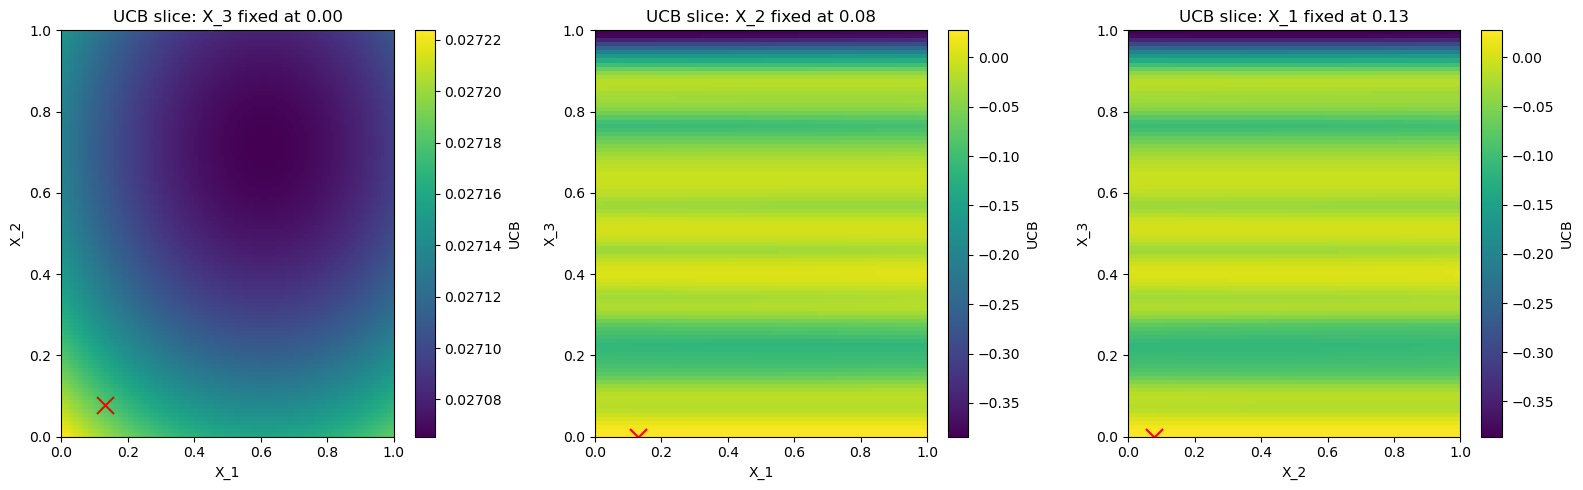

In [90]:
grid_res  = 100
lin       = np.linspace(0, 1, grid_res)
pairs     = [(0, 1, 2), (0, 2, 1), (1, 2, 0)]  # (dim_x, dim_y, dim_fixed)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (dx, dy, dfixed) in zip(axes, pairs):
    gx, gy             = np.meshgrid(lin, lin)
    grid_points        = np.zeros((grid_res * grid_res, 3))
    grid_points[:, dx] = gx.ravel()
    grid_points[:, dy] = gy.ravel()
    grid_points[:, dfixed] = next_point[dfixed]

    mu_grid, std_grid = gpr.predict(grid_points, return_std = True)
    ucb_grid          = (mu_grid + beta * std_grid).reshape(grid_res, grid_res)

    im = ax.imshow(ucb_grid, origin = "lower", extent = [0, 1, 0, 1], cmap = "viridis", aspect = "auto")
    ax.set_xlabel(labels[dx]); ax.set_ylabel(labels[dy])
    ax.set_title(f"UCB slice: {labels[dfixed]} fixed at {next_point[dfixed]:.2f}")
    ax.scatter(next_point[dx], next_point[dy], c = "red", marker = "x", s = 150, edgecolor = "black")
    plt.colorbar(im, ax=ax, label = "UCB")

plt.tight_layout()
plt.show()

# Portal Submission 

In [82]:
# Format as required by the capstone portal: x1-x2 (6 decimal places)
submission_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}"
print("Points to be submitted(Week 1):", submission_str)
print()

Points to be submitted(Week 1): 0.130658-0.076877-0.000068

